       DIABETES RISK ANALYSIS 

Dataset loaded successfully!
Dataset shape: (768, 9)

DATASET INFORMATION

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  DiabetesPedigreeFunction  Age  Outcome
0            6      148           72.0             35    169.5  33.6                     0.627   50        1
1            1       85           66.0             29    102.5  26.6                     0.351   31        0
2            8      183           64.0             32    169.5  23.3                     0.672   32        1
3            1       89           66.0             23     94.0  28.1                     0.167   21        0
4            0      137           40.0             35    168.0  43.1                     2.288   33        1

Dataset shape:
(768, 9)

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex:

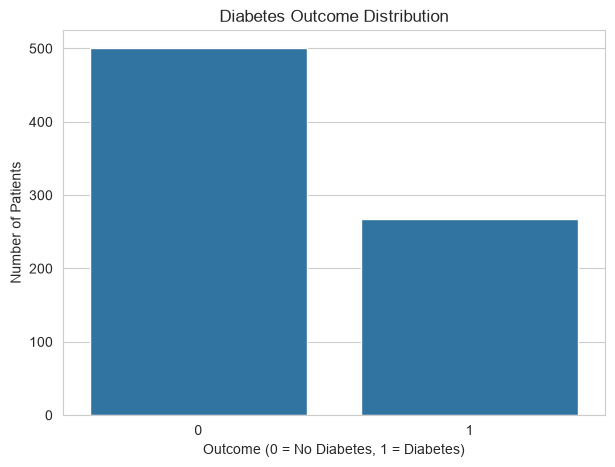

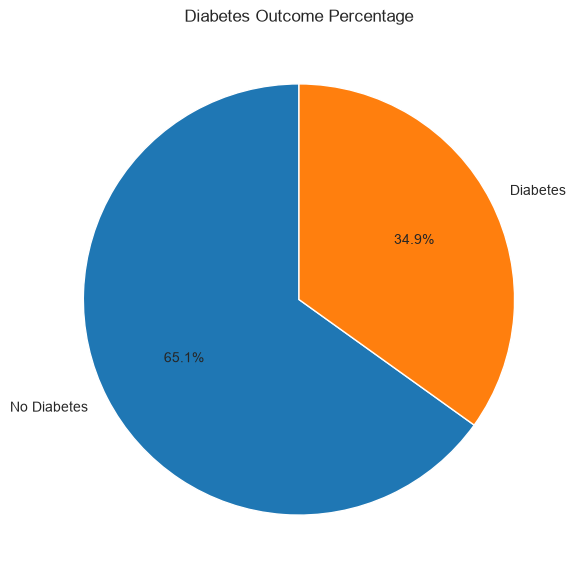

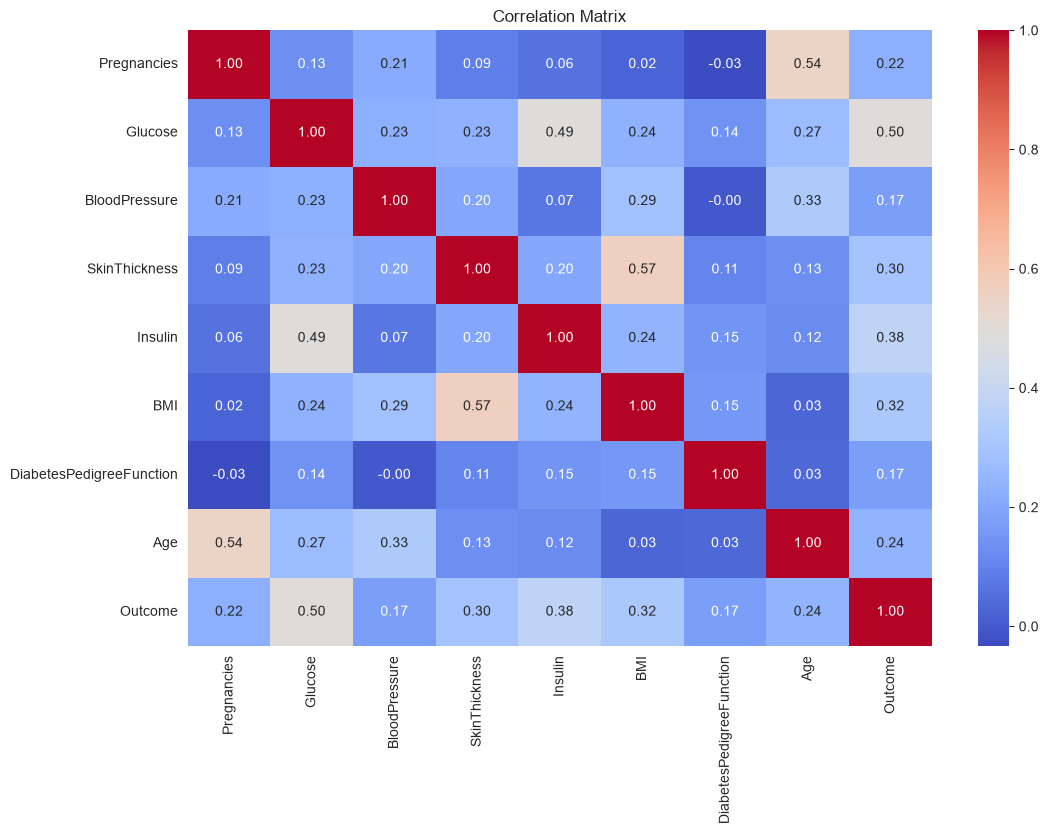

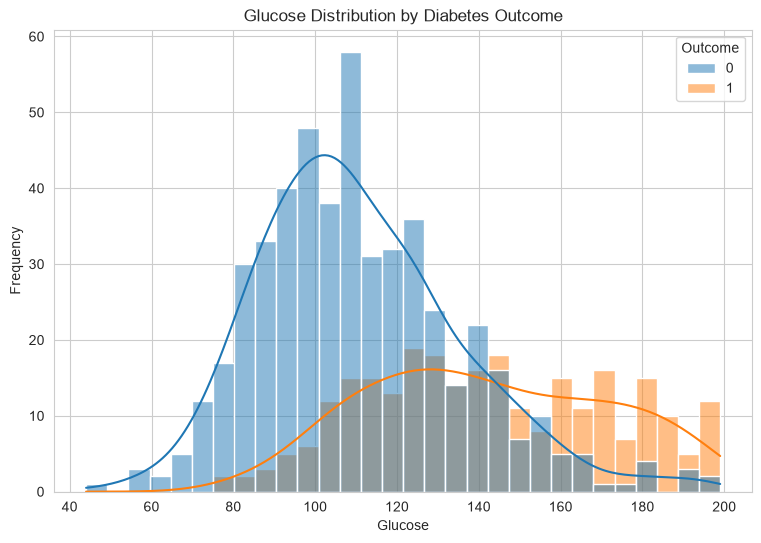

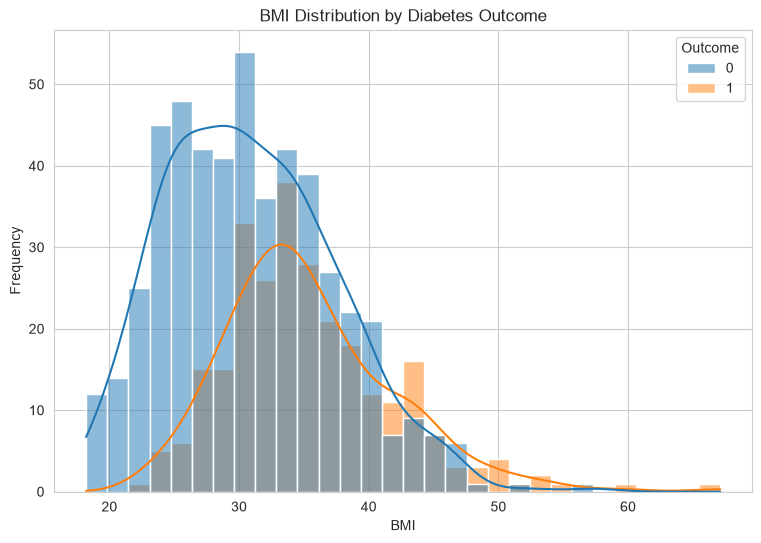

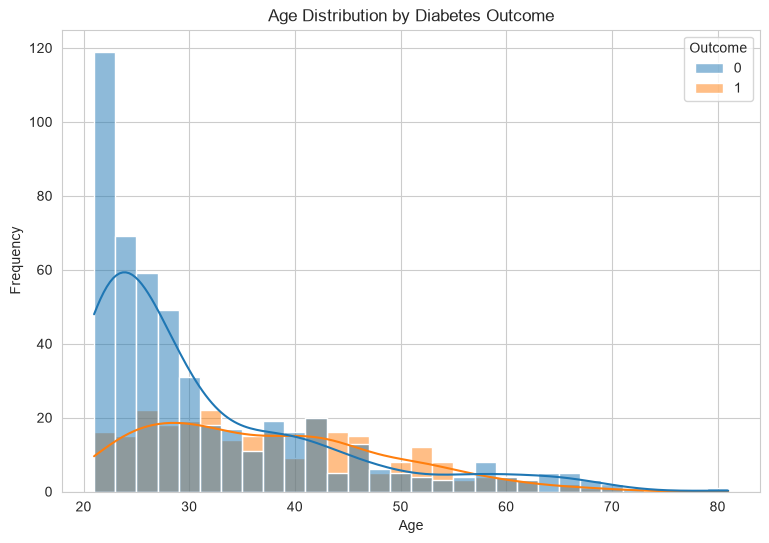

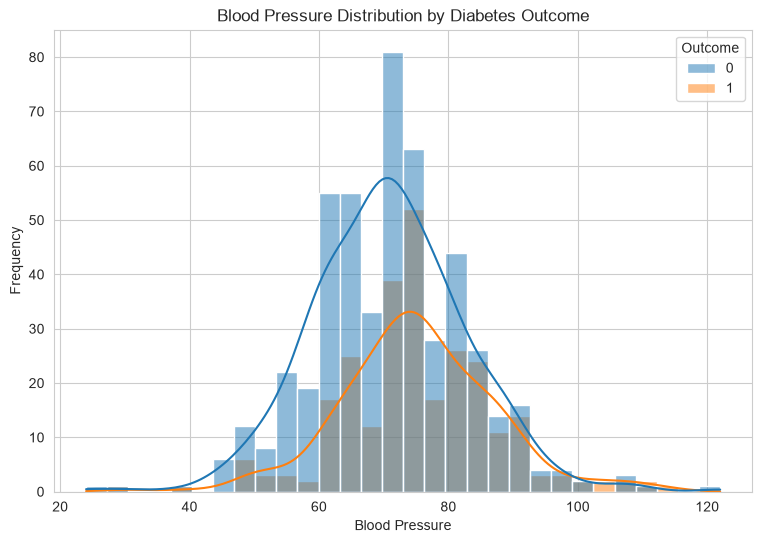

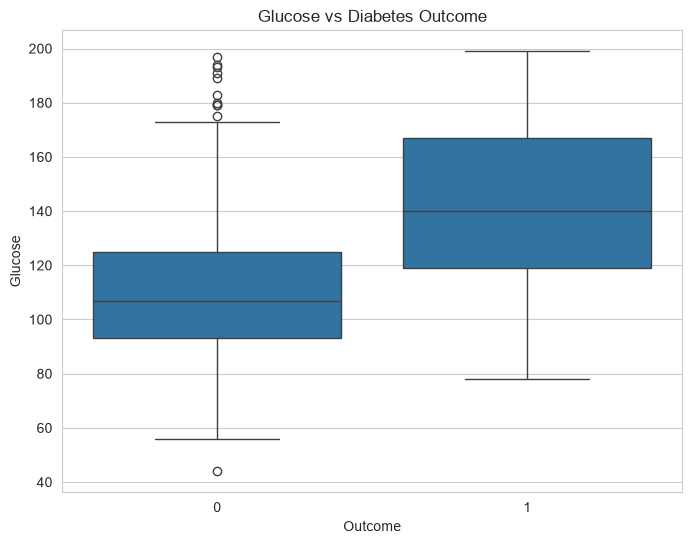

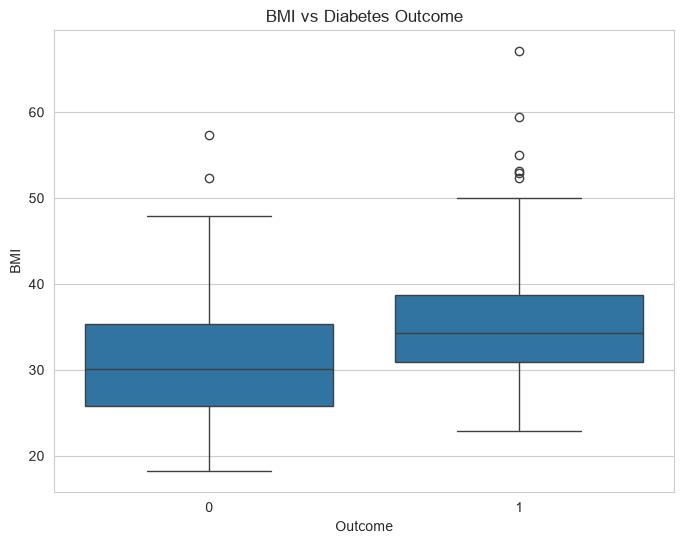

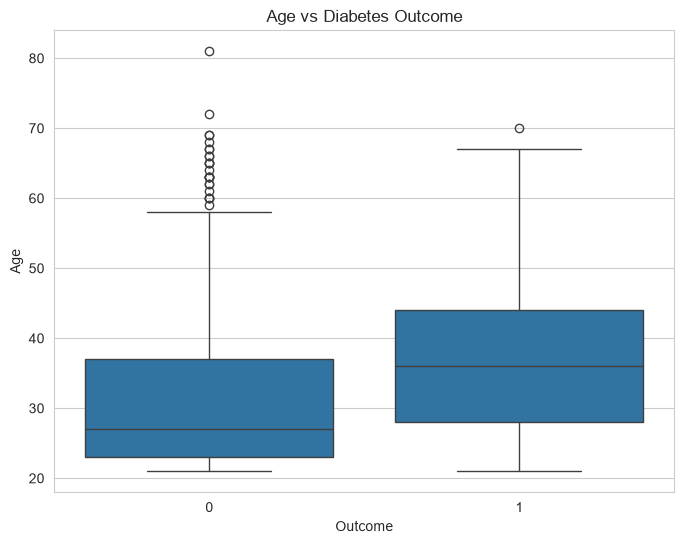

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

sns.set_style("whitegrid")

print("=" * 70)
print("       DIABETES RISK ANALYSIS ")
print("=" * 70)

df = pd.read_csv("diabetes.csv")

print("\nDataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
print(df.describe())

print("\n" + "=" * 70)
print("DATA QUALITY CHECK")
print("=" * 70)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

df = df.drop_duplicates()

print("\nShape after removing duplicates:")
print(df.shape)

zero_columns = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

print("\nInvalid zero values:")

for column in zero_columns:
    print(column, ":", (df[column] == 0).sum())

df[zero_columns] = df[zero_columns].replace(0, np.nan)

for column in zero_columns:
    df[column] = df[column].fillna(df[column].median())

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\n" + "=" * 70)
print("TARGET VARIABLE")
print("=" * 70)

print("\nOutcome counts:")
print(df["Outcome"].value_counts())

print("\nOutcome percentages:")
print((df["Outcome"].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Outcome")

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")

plt.show()

plt.figure(figsize=(7, 7))

outcome_counts = df["Outcome"].value_counts()

plt.pie(outcome_counts,labels=["No Diabetes", "Diabetes"],autopct="%1.1f%%",startangle=90)

plt.title("Diabetes Outcome Percentage")

plt.show()

plt.figure(figsize=(12, 8))

sns.heatmap(df.corr(),annot=True,fmt=".2f",cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

plt.figure(figsize=(9, 6))

sns.histplot(data=df,x="Glucose",hue="Outcome",kde=True,bins=30)

plt.title("Glucose Distribution by Diabetes Outcome")
plt.xlabel("Glucose")
plt.ylabel("Frequency")

plt.show()

plt.figure(figsize=(9, 6))

sns.histplot(data=df,x="BMI",hue="Outcome",kde=True,bins=30)

plt.title("BMI Distribution by Diabetes Outcome")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

plt.figure(figsize=(9, 6))

sns.histplot(data=df,x="Age",hue="Outcome",kde=True,bins=30)

plt.title("Age Distribution by Diabetes Outcome")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

plt.figure(figsize=(9, 6))

sns.histplot(data=df,x="BloodPressure",hue="Outcome",kde=True,bins=30)

plt.title("Blood Pressure Distribution by Diabetes Outcome")
plt.xlabel("Blood Pressure")
plt.ylabel("Frequency")

plt.show()

plt.figure(figsize=(8, 6))

sns.boxplot(data=df,x="Outcome",y="Glucose")

plt.title("Glucose vs Diabetes Outcome")

plt.show()

plt.figure(figsize=(8, 6))

sns.boxplot(data=df,x="Outcome",y="BMI")

plt.title("BMI vs Diabetes Outcome")

plt.show()

plt.figure(figsize=(8, 6))

sns.boxplot(data=df,x="Outcome",y="Age")

plt.title("Age vs Diabetes Outcome")

plt.show()
